In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Removed font settings as 'Times New Roman' is not found in the environment.
# plt.rcParams['font.family'] = 'Times New Roman']
# plt.rcParams['font.serif'] = ['Times New Roman']


def upload_plt_to_gcs(num_fig, step, fig):
    """Uploads a matplotlib figure to GCS (mock function)."""
    print(f"Uploading Figure {num_fig} for step {step} to GCS.")


# 1. DATA LOADING AND PREPROCESSING (Modified to return clean DF without LPA/Anomaly initially)
def load_base_rainfall_data(file_path, sheet_name=None):
    xls = pd.ExcelFile(file_path)
    if sheet_name is None:
        # If sheet_name is not provided, try to find an appropriate sheet
        if 'Whole India' in xls.sheet_names:
            sheet_name = 'Whole India'
        elif len(xls.sheet_names) > 0:
            sheet_name = xls.sheet_names[0] # Use the first sheet found
            print(f"Using first sheet found: '{sheet_name}' from {xls.sheet_names}")
        else:
            raise ValueError("No sheets found in the Excel file.")

    df_raw = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df_raw.iloc[1:].copy() # Skip the first row which often contains headers/units
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df['Annual'] = pd.to_numeric(df['Annual'], errors='coerce') # Keep 'Annual' for reference, but we'll create 'Traditional_Annual'
    df = df.dropna(subset=['Year', 'Annual']) # Drop rows where Year or Annual are NaN
    df['Year'] = df['Year'].astype(int) # Convert Year to integer type
    return df

# Function to calculate traditional annual rainfall (April to March)
def calculate_traditional_annual_rainfall(df_original):
    # This function is being skipped because the loaded data already contains 'Annual' rainfall.
    # The 'Annual' column from df_raw_data will be used as 'Traditional_Annual'.
    # The original intent of this function was to sum monthly data, which is not available in the current input.
    return df_original[['Year', 'Annual']].rename(columns={'Annual': 'Traditional_Annual'})


# Updated categorize_actual function based on detailed IMD classification (standalone)
def categorize_actual(anomaly):
    if anomaly >= 60: return 'Large Excess'
    elif anomaly >= 20 and anomaly < 60: return 'Excess'
    elif anomaly >= -19 and anomaly <= 19: return 'Normal'
    elif anomaly >= -59 and anomaly < -19: return 'Deficient'
    elif anomaly < -59: return 'Large Deficient'
    else: return 'Unknown'


# 2. IMPLEMENTATION OF TRADITIONAL MODELS (24 ACTIVE MODELS) - This function remains as is
def run_traditional_logic(year_ce):
    saka = year_ce - 78
    vikrama = year_ce + 57
    saka_century, saka_last_two = saka // 100, saka % 100
    v_cent, v_last = vikrama // 100, vikrama % 100

    res = {}
    # Basic Cycles and Planets
    res['MGM_5_4'] = 'Excess' if (saka * 3 + 2) % 4 in [1, 3] else 'Deficient'
    planets = {1: 'Sun', 2: 'Moon', 3: 'Mars', 4: 'Mercury', 5: 'Jupiter', 6: 'Venus', 0: 'Saturn'}
    res['KSP_Published_RG'] = planets.get((saka * 3 + 2) % 7)
    res['KSP_MS1_RG'] = planets.get((saka * 4 + 2) % 7)
    res['KSP_MS2_RG'] = planets.get((saka * 3 + 3) % 7)

    # Classical Outcomes
    # Updated based on user input: Samvatsaraphalaṁ counted with elapsed Saka year (saka % 12)
    res['Samvatsaraphalaṁ'] = {1: 'Excess', 2: 'Excess', 3: 'Large Deficient', 4: 'Deficient', 5: 'Excess', 6: 'Normal', 7: 'Normal', 8: 'Deficient', 9: 'Excess', 10: 'Large Excess', 11: 'Large Deficient', 0: 'Deficient'}.get((saka + 1) % 12)
    res['Aṣṭhahasti'] = {0: 'Excess', 1: 'Normal', 2: 'Deficient', 3: 'Normal', 4: 'Deficient', 5: 'Excess', 6: 'Excess', 7: 'Normal'}.get((saka + 4) % 8)
    res['Kṛsaka'] = {1: 'Excess', 2: 'Normal', 3: 'Deficient'}.get((saka + 1) % 4, 'Unknown')
    res['Āḍhaka'] = {0: 'Deficient', 1:'Normal', 2: 'Excess', 3: 'Normal'}.get((saka + 4) % 4)

    # Logic Based / Eras
    # MGM_4_21 (Updated calculation and mapping)
    R_4_21 = (saka_century + saka_last_two + 4) % 7
    # Updated mapping for MGM_4_21 based on user input
    res['MGM_4_21'] = {1:'Deficient', 4:'Deficient', 2:'Excess', 5:'Excess', 3:'Normal', 6:'Normal', 0:'Large Deficient'}.get(R_4_21)

    # Rudradevamataṁ was identified as MGM_4_21 and is now merged by removing redundancy.

    kala = (((v_cent + v_last) * 3) + 5) % 7
    res['MGM_4_23'] = 'Excess' if kala in [2, 3, 5, 6] else ('Normal' if kala in [1, 4] else 'Deficient')

    # DBS Series
    res['DBS_Śaka'] = {1:'Normal', 2:'Normal', 3:'Deficient', 4:'Deficient', 5:'Normal', 6:'Normal', 0:'None'}.get((saka * 2 + 3) % 7, 'Inauspicious')

    vikrama_calc = (vikrama * 3 + 5) % 7
    if vikrama_calc in [1, 2, 3]:
        res['DBS_Vikrama'] = 'Normal'
    elif vikrama_calc == 4:
        res['DBS_Vikrama'] = 'Deficient'
    elif vikrama_calc == 5:
        res['DBS_Vikrama'] = 'Normal'
    elif vikrama_calc == 6:
        res['DBS_Vikrama'] = 'Excess'
    elif vikrama_calc == 0:
        res['DBS_Vikrama'] = 'Large Deficient'

    res['MGM_4_9'] = {1:'Deficient', 6:'Deficient', 3:'Normal', 5:'Normal', 2:'Excess', 4:'Excess', 0:'Large Deficient'}.get(((vikrama + saka) * 2) % 7)
    res['MGM_4_11'] = {2:'Excess', 4:'Excess', 3:'Deficient', 5:'Deficient', 0:'Large Deficient', 6:'Large Deficient', 1:'Normal'}.get(((vikrama + saka) * 3 + 5) % 7)

    # MGM_4_13_Cent (Updated calculation and mapping)
    R_4_13 = (3 * (saka_century + saka_last_two) + 5) % 7
    res['MGM_4_13_Cent'] = {2:'Excess', 4:'Excess', 3:'Deficient', 5:'Deficient', 0:'Large Deficient', 6:'Large Deficient', 1:'Normal'}.get(R_4_13)

    # MGM_4_14 (Chained Iterative Remainder Model) +
    r1_4_14 = (3 * saka) % 7
    R_4_14 = (2 * r1_4_14 + 5) % 7
    res['MGM_4_14'] = {1:'Deficient', 4:'Deficient', 2:'Excess', 5:'Excess', 3:'Normal', 6:'Normal', 0:'Large Deficient'}.get(R_4_14)

    res['MGM_4_15'] = {1:'Deficient', 4:'Deficient', 2:'Excess', 5:'Excess', 3:'Normal', 6:'Normal', 0:'Large Deficient'}.get((saka * 2 - 3) % 7)

    # MGM_4_24 (Updated calculation and mapping)
    R_4_24 = (2 * saka_last_two + 1) % 7
    res['MGM_4_24'] = {2:'Excess', 3:'Excess', 5:'Excess', 6:'Excess', 1:'Normal', 4:'Normal', 0:'Deficient'}.get(R_4_24)

    res['MGM_4_17'] = {2:'Excess', 3:'Excess', 4:'Excess', 5:'Deficient', 7:'Deficient', 8:'Deficient', 6:'Normal', 1:'Normal', 0:'Normal'}.get((saka * 2 - 3) % 9)
    res['MGM_4_25'] = {2:'Excess', 3:'Excess', 4:'Excess', 6:'Normal', 0:'Normal', 5:'Deficient', 7:'Deficient', 8:'Deficient'}.get((saka * 2 + 3) % 9)

    # MGM_4_19
    r1_4_19 = (3 * saka) % 7
    R_4_19 = (5 * r1_4_19) % 3
    res['MGM_4_19'] = {1:'Excess', 2:'Normal', 0:'Deficient'}.get(R_4_19)


    r1_26_28 = (3 * saka) % 7
    V_varsa = (2 * r1_26_28) + 5
    R_final_26_28 = (3 * V_varsa + 3) % 7
    res['MGM_4_26-28'] = {
        0: 'Large Deficient',
        1: 'Deficient',
        4: 'Deficient',
        2: 'Excess',
        5: 'Excess',
        3: 'Normal',
        6: 'Normal'
    }.get(R_final_26_28)
    return pd.Series(res)

# RUNNING ANALYSIS (Initial setup - load raw data only)
file_path = '/content/All India Monthly and Seasonal Rainfall (mm) Series _ Whole India.xlsx'

# Diagnostic: Verify file existence before attempting to load
print(f"Checking for file: {file_path}")
!ls -l "{file_path}" # Using quotes in case of spaces in filename

df_raw_data = load_base_rainfall_data(file_path)
df_whole = df_raw_data.rename(columns={'Annual': 'Traditional_Annual'})

display(df_whole.head())

Checking for file: /content/All India Monthly and Seasonal Rainfall (mm) Series _ Whole India.xlsx
-rw-r--r-- 1 root root 82862 Aug 16 06:50 '/content/All India Monthly and Seasonal Rainfall (mm) Series _ Whole India.xlsx'


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Traditional_Annual,Winter Season,Pre-Monsoon Season,Monsoon Season,Post-Monsoon Season
1,1901,33.7,36.9,17.9,37.6,52.4,112.3,241.5,268.9,126.1,51.6,38.3,10.0,1027.3,70.6,108,748.8,99.9
2,1902,7.4,4.1,18.7,44.2,47.8,109.0,283.2,202.1,201.0,62.9,28.9,25.2,1034.5,11.5,110.7,795.2,117
3,1903,17.0,8.3,30.8,17.2,59.1,117.0,292.0,272.0,200.1,120.2,40.3,18.2,1192.3,25.3,107.1,881.1,178.7
4,1904,15.1,9.7,31.8,32.8,72.9,164.4,261.4,204.1,130.6,68.7,11.4,16.4,1019.2,24.8,137.5,760.4,96.4
5,1905,25.2,20.8,42.1,33.5,54.4,92.3,251.7,201.3,177.4,53.7,9.8,10.4,972.7,46.1,130.1,722.7,73.9


In [2]:
# Re-applying traditional models and simplifying statuses to reflect the updated logic
# Define the period for analysis
start_year = 1951
end_year = 2023 # Updated: 1951 + 72 years

# Prepare an empty list to store processed data for each year
processed_data_list = []
decadal_lp_averages = {} # Store calculated LPAs for each decade

for current_year in range(start_year, end_year + 1):
    # Determine the start year of the current decade (e.g., 1964 -> 1960)
    decade_start_year = (current_year // 10) * 10

    # Calculate LPA for the decade if not already calculated
    if decade_start_year not in decadal_lp_averages:
        # The 50-year window should precede the start of the current decade
        lpa_window_start_year = decade_start_year - 50
        lpa_window_end_year = decade_start_year - 1

        # Get data for the 50-year window to calculate LPA for the decade
        lpa_data_window_for_decade = df_whole[(df_whole['Year'] >= lpa_window_start_year) & (df_whole['Year'] <= lpa_window_end_year)]

        if not lpa_data_window_for_decade.empty:
            decadal_lp_averages[decade_start_year] = lpa_data_window_for_decade['Traditional_Annual'].mean()
        else:
            # If no sufficient historical data for the 50-year LPA for this decade, set to None or handle as appropriate
            decadal_lp_averages[decade_start_year] = None

    lpa_for_current_year = decadal_lp_averages.get(decade_start_year)

    # Get rainfall data for the current year
    current_year_data = df_whole[df_whole['Year'] == current_year]

    if not current_year_data.empty and lpa_for_current_year is not None:
        annual_rainfall_current_year = current_year_data['Traditional_Annual'].iloc[0]
        # Calculate Anomaly_Pct for the current year using its specific LPA
        if lpa_for_current_year != 0: # Avoid division by zero
            anomaly_pct_current_year = ((annual_rainfall_current_year - lpa_for_current_year) / lpa_for_current_year) * 100
        else:
            anomaly_pct_current_year = 0

        # Categorize Actual_Status
        actual_status_current_year = categorize_actual(anomaly_pct_current_year)

        # Add these calculated values to the current year's data
        temp_df = current_year_data.copy()
        temp_df.loc[:, 'LPA_50yr'] = lpa_for_current_year
        temp_df.loc[:, 'Anomaly_Pct'] = anomaly_pct_current_year
        temp_df.loc[:, 'Actual_Status'] = actual_status_current_year
        processed_data_list.append(temp_df)
    else:
        # This case handles years where no rainfall data is found or LPA could not be computed for the decade.
        pass

# Concatenate all processed yearly data into a single DataFrame
df_dynamic_lpa = pd.concat(processed_data_list, ignore_index=True)

# Apply traditional models to the dynamically processed data
model_results_dynamic_lpa = df_dynamic_lpa['Year'].apply(run_traditional_logic)
final_df_dynamic_lpa = pd.concat([df_dynamic_lpa, model_results_dynamic_lpa], axis=1)

# Define the standard IMD categories (moved from cell 2tbtVhvO-Sl7 to ensure up-to-date definition)
IMD_CATEGORIES = ['Large Excess', 'Excess', 'Normal', 'Deficient', 'Large Deficient']

# Define a comprehensive mapping for traditional model outcomes
comprehensive_category_mapping = {
    'Sun': 'Deficient',
    'Moon': 'Large Excess',
    'Mars': 'Deficient',
    'Mercury': 'Normal',
    'Jupiter': 'Normal',
    'Venus': 'Excess',
    'Saturn': 'Large Deficient'
}

def map_traditional_to_simplified_status(value):
    if value in IMD_CATEGORIES:
        return value
    return comprehensive_category_mapping.get(value, 'Unknown_Category')

# Apply the mapping to each traditional model result column
traditional_model_cols = model_results_dynamic_lpa.columns

for col in traditional_model_cols:
    final_df_dynamic_lpa[f'{col}_Simplified_Status'] = final_df_dynamic_lpa[col].apply(map_traditional_to_simplified_status)

print(f"Re-performance initialized. Data window: {final_df_dynamic_lpa['Year'].min()} to {final_df_dynamic_lpa['Year'].max()}.")
display(final_df_dynamic_lpa.head())

# Define simplified_cols here to ensure it's available for subsequent cells
simplified_cols = [f'{col}_Simplified_Status' for col in traditional_model_cols]


Re-performance initialized. Data window: 1951 to 2023.


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,...,MGM_4_9_Simplified_Status,MGM_4_11_Simplified_Status,MGM_4_13_Cent_Simplified_Status,MGM_4_14_Simplified_Status,MGM_4_15_Simplified_Status,MGM_4_24_Simplified_Status,MGM_4_17_Simplified_Status,MGM_4_25_Simplified_Status,MGM_4_19_Simplified_Status,MGM_4_26-28_Simplified_Status
0,1951,15.8,12.2,44.3,55.2,58.3,160.1,249.5,221.3,123.3,...,Deficient,Large Deficient,Deficient,Deficient,Excess,Deficient,Deficient,Deficient,Excess,Normal
1,1952,10.6,19.9,37.3,32.1,68.3,163.7,284.7,256.1,118.4,...,Normal,Large Deficient,Normal,Large Deficient,Large Deficient,Excess,Normal,Deficient,Normal,Normal
2,1953,30.3,10.6,25.0,38.0,46.3,162.4,321.1,299.7,178.3,...,Large Deficient,Deficient,Excess,Normal,Excess,Normal,Excess,Normal,Normal,Large Deficient
3,1954,37.7,37.4,17.2,23.2,52.5,141.1,293.8,230.8,246.8,...,Excess,Excess,Large Deficient,Excess,Deficient,Excess,Deficient,Excess,Deficient,Deficient
4,1955,22.0,4.4,24.4,31.9,71.5,174.7,233.5,321.7,218.0,...,Deficient,Deficient,Deficient,Deficient,Normal,Normal,Deficient,Excess,Deficient,Deficient


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

chi_square_results = []

# Ensure all IMD_CATEGORIES are present for consistent table dimensions
# and to handle cases where a category might be missing in a specific model's prediction
IMD_CATEGORIES = ['Large Excess', 'Excess', 'Normal', 'Deficient', 'Large Deficient']

# Check if traditional_model_cols is defined, if not, try to infer it
if 'traditional_model_cols' not in globals() and 'traditional_model_cols' not in locals():
    if 'final_df_dynamic_lpa' in globals() or 'final_df_dynamic_lpa' in locals():
        # Infer traditional_model_cols from final_df_dynamic_lpa
        # Assuming model_simplified_cols are named as '{model_name}_Simplified_Status'
        simplified_status_cols = [col for col in final_df_dynamic_lpa.columns if col.endswith('_Simplified_Status')]
        traditional_model_cols = [col.replace('_Simplified_Status', '') for col in simplified_status_cols]
        print("Inferred 'traditional_model_cols' from 'final_df_dynamic_lpa'. Please ensure cell 9a2e0fb9 was executed correctly.")
    else:
        print("Error: 'traditional_model_cols' is not defined and 'final_df_dynamic_lpa' is not available. Please ensure all preceding data processing cells have been executed.")
        # Cannot proceed without these, so we'll make chi_square_results empty and exit gracefully.
        chi_square_df = pd.DataFrame([])
        display(chi_square_df)
        # Exit the cell execution here if possible, but for simplicity we'll just return an empty df.
else:
    # If traditional_model_cols is defined, proceed with the calculation
    for col in traditional_model_cols:
        model_simplified_col = f'{col}_Simplified_Status'

        if model_simplified_col not in final_df_dynamic_lpa.columns:
            print(f"Warning: Model column '{model_simplified_col}' not found. Skipping.")
            continue

        # Filter data to include only valid IMD categories for both actual and predicted statuses
        filtered_df = final_df_dynamic_lpa[
            final_df_dynamic_lpa['Actual_Status'].isin(IMD_CATEGORIES) &
            final_df_dynamic_lpa[model_simplified_col].isin(IMD_CATEGORIES)
        ].copy()

        if filtered_df.empty:
            chi_square_results.append({
                'Model': col,
                'Chi2': 0.0,
                'P_Value': 1.0,
                'Cramers_V': 0.0
            })
            continue

        # Create a contingency table
        contingency_table = pd.crosstab(
            filtered_df[model_simplified_col],
            filtered_df['Actual_Status']
        ).reindex(index=IMD_CATEGORIES, columns=IMD_CATEGORIES, fill_value=0)

        # Remove rows and columns that sum to zero to avoid ValueError in chi2_contingency
        contingency_table = contingency_table.loc[(contingency_table != 0).any(axis=1), (contingency_table != 0).any(axis=0)]

        chi2_stat = 0.0
        p_value = 1.0
        cramers_v = 0.0

        # Check if the contingency table is valid for chi2_contingency
        if contingency_table.empty or contingency_table.sum().sum() == 0 or min(contingency_table.shape) < 2:
            # Not enough data or categories for a meaningful chi-square test
            pass
        else:
            try:
                chi2, p, dof, expected = chi2_contingency(contingency_table)
                chi2_stat = chi2
                p_value = p

                # Calculate Cramer's V
                n = contingency_table.sum().sum()
                min_dim = min(contingency_table.shape) - 1
                if min_dim > 0: # Avoid division by zero
                    cramers_v = np.sqrt(chi2_stat / (n * min_dim))
                else:
                    cramers_v = 0.0 # No variability, Cramer's V is 0
            except ValueError as e:
                # This can happen if expected frequencies are zero, even after filtering
                print(f"Could not calculate Chi-Square for model {col} due to ValueError: {e}")
                # Keep chi2_stat=0.0, p_value=1.0, cramers_v=0.0 as defaults

        chi_square_results.append({
            'Model': col,
            'Chi2': chi2_stat,
            'P_Value': p_value,
            'Cramers_V': cramers_v
        })

    chi_square_df = pd.DataFrame(chi_square_results)

    # Sort by Cramer's V (descending) for better interpretation
    chi_square_df = chi_square_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)

    print("\nChi-Square Test Results:")
    display(chi_square_df.head())


Chi-Square Test Results:


,Model,Chi2,P_Value,Cramers_V
0,MGM_4_24,17.633766,0.000148,0.491486
1,KSP_Published_RG,8.406061,0.077786,0.339340
2,MGM_4_15,7.252597,0.064268,0.315199
3,KSP_MS1_RG,7.252597,0.123127,0.315199
4,KSP_MS2_RG,4.011915,0.404396,0.234431


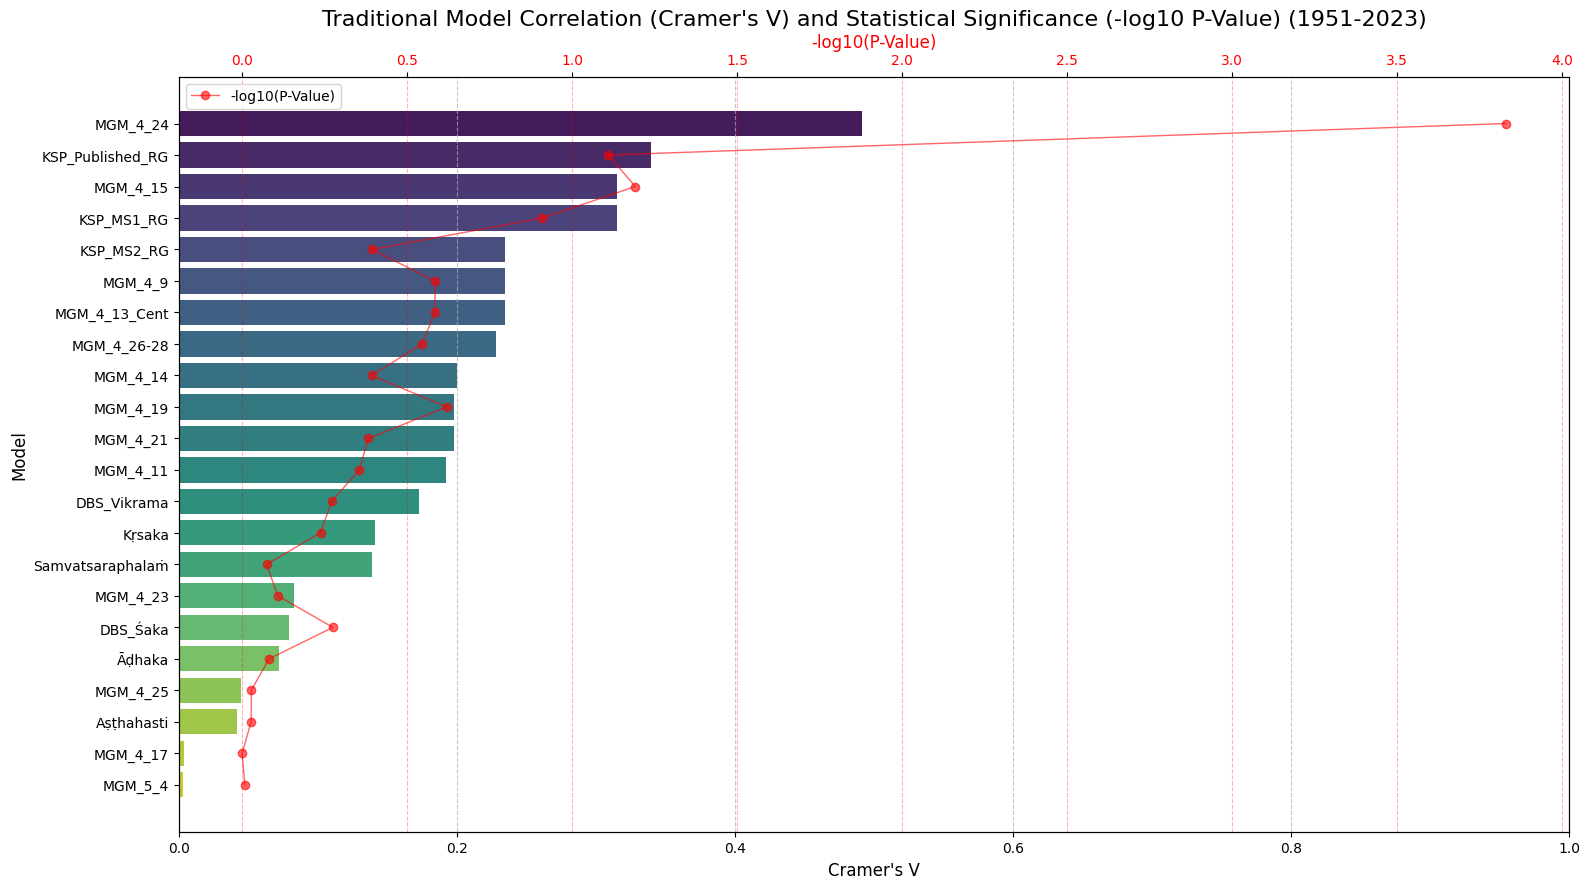

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure -log10_P_Value is available for plotting
# Handle potential P_Value = 0 by replacing with a very small number to avoid log(0)
chi_square_df['P_Value_for_log'] = chi_square_df['P_Value'].replace(0, np.finfo(float).eps)
chi_square_df['neg_log10_P_Value'] = -np.log10(chi_square_df['P_Value_for_log'])

# Sort by Cramer's V for consistent plotting order
chi_square_df_sorted = chi_square_df.sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(16, 9))

# Plot Cramer's V as bars on the primary y-axis
sns.barplot(x='Cramers_V', y='Model', data=chi_square_df_sorted, palette='viridis', ax=ax1, hue='Model', legend=False)
ax1.set_xlabel("Cramer's V", fontsize=12)
ax1.set_ylabel('Model', fontsize=12)
ax1.set_xlim(0, 1) # Cramer's V ranges from 0 to 1
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.7)

# Create a secondary x-axis for -log10 P-Value
ax2 = ax1.twiny() # Create a twin Axes sharing the y-axis

# Plot -log10 P-Value as scatter points on the secondary x-axis
ax2.plot(chi_square_df_sorted['neg_log10_P_Value'], chi_square_df_sorted['Model'],
         marker='o', linestyle='-', color='red', label='-log10(P-Value)', markersize=6, alpha=0.6, linewidth=1.0, zorder=3)
ax2.set_xlabel('-log10(P-Value)', color='red', fontsize=12)
ax2.tick_params(axis='x', labelcolor='red', labelsize=10)

# Add gridlines for the secondary axis for better readability
ax2.grid(axis='x', linestyle='--', alpha=0.3, color='red')

# Add legend for the secondary axis
ax2.legend(loc='upper left')

plt.title("Traditional Model Correlation (Cramer's V) and Statistical Significance (-log10 P-Value) (1951-2023)", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# @title step_artifacts
num_fig = "11" # @param {type:"string"}
step = 'ChiSquare_CramersV_PValue_Visualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "CorrelationAnalysis", "Summary", "CramersV_Visualization", "PValue_Visualization", "Combined_CramersV_PValue_Visualization", "Inter_Model_Correlation_Heatmap", "Comparative_Distribution_Plot", "Regional_CramersV_Heatmap", "Combined_Regional_Performance", "Regional_Combined_Performance_Plot", "ChiSquare_CramersV_PValue_Visualization"] {type:"string"}
upload_plt_to_gcs(num_fig, step, fig)


Uploading Figure 11 for step ChiSquare_CramersV_PValue_Visualization to GCS.


### Categorical Baseline Accuracy Analysis

This section calculates the classification accuracy for each traditional model, comparing its simplified categorical rainfall status predictions against the actual observed rainfall status. The models are then ranked by accuracy and visualized alongside the multi-model collective mean accuracy.

In [6]:
model_accuracies = []

for col in traditional_model_cols:
    model_simplified_col = f'{col}_Simplified_Status'

    if model_simplified_col not in final_df_dynamic_lpa.columns:
        print(f"Warning: Model column '{model_simplified_col}' not found. Skipping accuracy calculation for {col}.")
        continue

    # Calculate accuracy
    correct_predictions = (final_df_dynamic_lpa[model_simplified_col] == final_df_dynamic_lpa['Actual_Status']).sum()
    total_predictions = len(final_df_dynamic_lpa)

    if total_predictions > 0:
        accuracy = (correct_predictions / total_predictions) * 100
    else:
        accuracy = 0.0

    model_accuracies.append({'Model': col, 'Accuracy': accuracy})

accuracy_df = pd.DataFrame(model_accuracies)

# Calculate the multi-model collective mean accuracy
mean_accuracy = accuracy_df['Accuracy'].mean()

print("\nModel Accuracies:")
display(accuracy_df.sort_values(by='Accuracy', ascending=False).head())
print(f"\nMulti-Model Collective Mean Accuracy: {mean_accuracy:.2f}%")


Model Accuracies:


,Model,Accuracy
10,DBS_Śaka,58.904110
11,DBS_Vikrama,54.794521
7,Āḍhaka,50.684932
5,Aṣṭhahasti,36.986301
17,MGM_4_24,32.876712



Multi-Model Collective Mean Accuracy: 29.89%


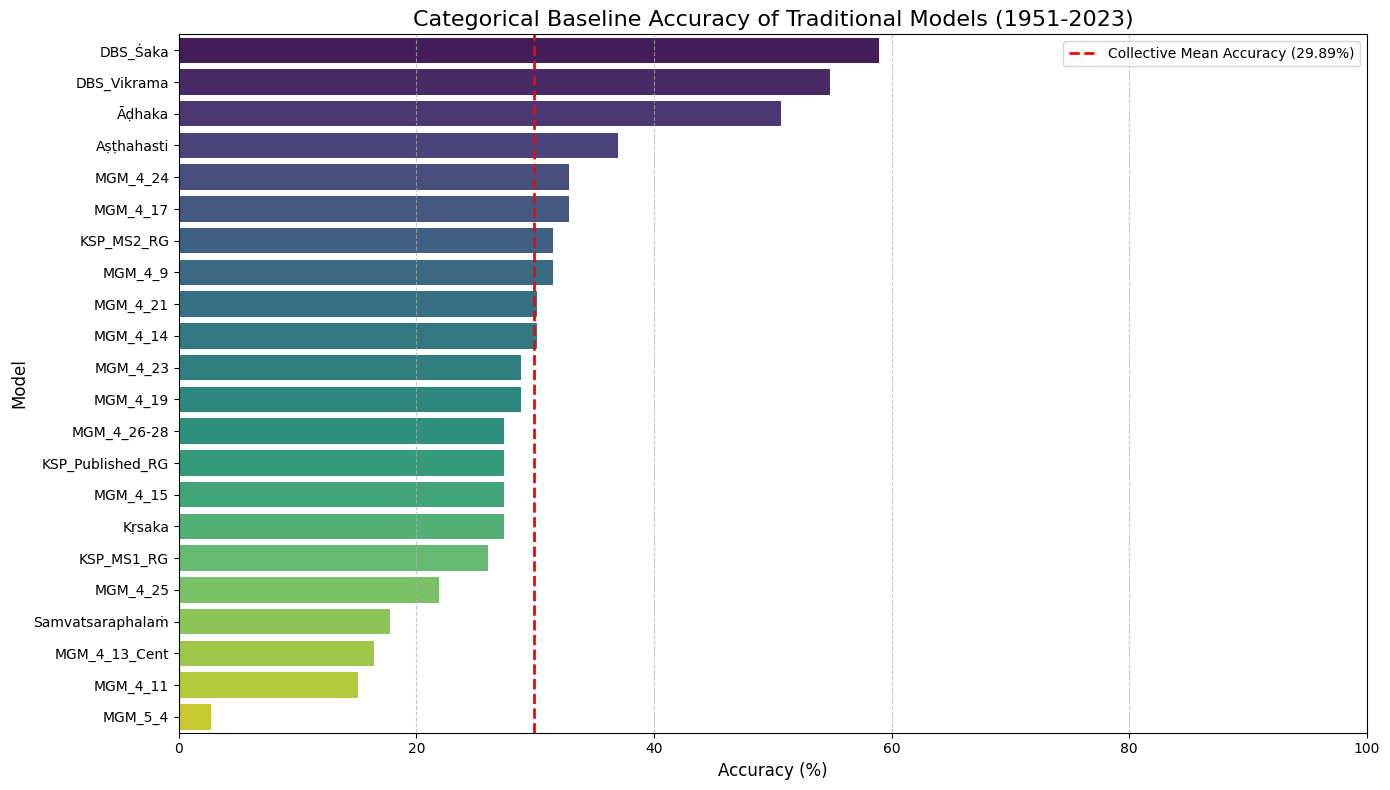

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by Accuracy for better visualization
accuracy_df_sorted = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(x='Accuracy', y='Model', data=accuracy_df_sorted, palette='viridis', ax=ax, hue='Model', legend=False)

# Add the multi-model collective mean accuracy line
ax.axvline(x=mean_accuracy, color='red', linestyle='--', linewidth=2, label=f'Collective Mean Accuracy ({mean_accuracy:.2f}%)')

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
ax.set_title('Categorical Baseline Accuracy of Traditional Models (1951-2023)', fontsize=16)
ax.set_xlim(0, 100) # Accuracy is a percentage
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# @title step_artifacts
num_fig = "12" # @param {type:"string"}
step = 'Categorical_Baseline_Accuracy_Analysis'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "CorrelationAnalysis", "Summary", "CramersV_Visualization", "PValue_Visualization", "Combined_CramersV_PValue_Visualization", "Inter_Model_Correlation_Heatmap", "Comparative_Distribution_Plot", "Regional_CramersV_Heatmap", "Combined_Regional_Performance", "Regional_Combined_Performance_Plot", "ChiSquare_CramersV_PValue_Visualization", "Categorical_Baseline_Accuracy_Analysis"] {type:"string"}
upload_plt_to_gcs(num_fig, step, fig)

Uploading Figure 12 for step Categorical_Baseline_Accuracy_Analysis to GCS.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Install xlsxwriter if not already installed
!pip install xlsxwriter --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00


### Inter-Model Redundancy and Covariance Mapping

This analysis aims to identify potential redundancy or systemic overlap among the 22 traditional models by calculating pairwise categorical cross-correlations. A symmetric matrix of Cramer's V coefficients is generated and visualized as an annotated heatmap.

In [ ]:
import itertools

# Ensure traditional_model_cols is defined
if 'traditional_model_cols' not in globals():
    simplified_status_cols = [col for col in final_df_dynamic_lpa.columns if col.endswith('_Simplified_Status')]
    traditional_model_cols = [col.replace('_Simplified_Status', '') for col in simplified_status_cols]

model_pairs = list(itertools.combinations(traditional_model_cols, 2))
cramers_v_matrix = pd.DataFrame(np.identity(len(traditional_model_cols)),
                                index=traditional_model_cols, columns=traditional_model_cols)

for model1, model2 in model_pairs:
    col1 = f'{model1}_Simplified_Status'
    col2 = f'{model2}_Simplified_Status'

    if col1 in final_df_dynamic_lpa.columns and col2 in final_df_dynamic_lpa.columns:
        # Create contingency table for the pair
        contingency_table_pair = pd.crosstab(
            final_df_dynamic_lpa[col1],
            final_df_dynamic_lpa[col2]
        )

        # Filter out rows/cols with no data for chi2_contingency robustness
        contingency_table_pair = contingency_table_pair.loc[(contingency_table_pair != 0).any(axis=1), (contingency_table_pair != 0).any(axis=0)]

        if not contingency_table_pair.empty and min(contingency_table_pair.shape) > 1:
            try:
                chi2, p, dof, expected = chi2_contingency(contingency_table_pair)
                n = contingency_table_pair.sum().sum()
                min_dim = min(contingency_table_pair.shape) - 1
                if min_dim > 0:
                    cramers_v = np.sqrt(chi2 / (n * min_dim))
                else:
                    cramers_v = 0.0 # No variability, Cramer's V is 0
            except ValueError:
                cramers_v = 0.0 # Handle cases where chi2_contingency fails
        else:
            cramers_v = 0.0 # Not enough data for meaningful calculation
    else:
        cramers_v = 0.0

    cramers_v_matrix.loc[model1, model2] = cramers_v
    cramers_v_matrix.loc[model2, model1] = cramers_v # Symmetric matrix

print("Pairwise Cramer's V Matrix (first 5x5):")
display(cramers_v_matrix.head())


In [ ]:
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, ax=ax)
plt.title('Inter-Model Cramer\'s V (Categorical Cross-Correlation) Heatmap', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "13" # @param {type:"string"}
step = 'Inter_Model_CramersV_Heatmap'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "CorrelationAnalysis", "Summary", "CramersV_Visualization", "PValue_Visualization", "Combined_CramersV_PValue_Visualization", "Inter_Model_Correlation_Heatmap", "Comparative_Distribution_Plot", "Regional_CramersV_Heatmap", "Combined_Regional_Performance", "Regional_Combined_Performance_Plot", "ChiSquare_CramersV_PValue_Visualization", "Categorical_Baseline_Accuracy_Analysis"] {type:"string"}
upload_plt_to_gcs(num_fig, step, fig)

### Proportional Distribution and Classification Bias Profiles

This section calculates the normalized frequency (proportion) for each of the five rainfall classifications for both the actual observed IMD data and for each traditional model's predictions. This helps diagnose systematic biases (e.g., overprediction of 'Excess', underprediction of 'Deficient') within individual models. The results are mapped into a grouped bar chart.

In [ ]:
distribution_data = []

# IMD Actual Distribution
imd_distribution = final_df_dynamic_lpa['Actual_Status'].value_counts(normalize=True).reindex(IMD_CATEGORIES, fill_value=0) * 100
for category, proportion in imd_distribution.items():
    distribution_data.append({'Source': 'IMD Actual', 'Category': category, 'Proportion': proportion})

# Model Distributions
for col in traditional_model_cols:
    model_simplified_col = f'{col}_Simplified_Status'
    if model_simplified_col in final_df_dynamic_lpa.columns:
        model_distribution = final_df_dynamic_lpa[model_simplified_col].value_counts(normalize=True).reindex(IMD_CATEGORIES, fill_value=0) * 100
        for category, proportion in model_distribution.items():
            distribution_data.append({'Source': col, 'Category': category, 'Proportion': proportion})

distribution_df = pd.DataFrame(distribution_data)

print("Proportional Distribution of Rainfall Categories (IMD Actual vs. Models - first 10 rows):")
display(distribution_df.head(10))

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.barplot(x='Source', y='Proportion', hue='Category', data=distribution_df, palette='viridis', ax=ax)
plt.title('Proportional Distribution of Rainfall Categories: IMD Actual vs. Traditional Models', fontsize=16)
plt.xlabel('Source (IMD Actual or Model)', fontsize=12)
plt.ylabel('Proportion (%)', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "14" # @param {type:"string"}
step = 'Proportional_Distribution_Bias_Profiles'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "CorrelationAnalysis", "Summary", "CramersV_Visualization", "PValue_Visualization", "Combined_CramersV_PValue_Visualization", "Inter_Model_Correlation_Heatmap", "Comparative_Distribution_Plot", "Regional_CramersV_Heatmap", "Combined_Regional_Performance", "Regional_Combined_Performance_Plot", "ChiSquare_CramersV_PValue_Visualization", "Categorical_Baseline_Accuracy_Analysis", "Proportional_Distribution_Bias_Profiles"] {type:"string"}
upload_plt_to_gcs(num_fig, step, fig)

In [ ]:
import pandas as pd

file_path = '/content/All India Monthly and Seasonal Rainfall (mm) Series _ Whole India.xlsx'

# Read all sheet names from the Excel file
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names

print(f"Sheets found in '{file_path}': {sheet_names}")

# Now, define the regions we expect based on the user's description and actual sheet names
EXPECTED_REGIONS = [
    'Whole India',
    'Central India',
    'Peninslar India', # Corrected: 'Peninslar' instead of 'Peninsular'
    'North-West India',
    'North East India' # Corrected: 'North East' instead of 'North-East'
]

# Check if all expected regional sheets are present
missing_regions = [region for region in EXPECTED_REGIONS if region not in sheet_names]

if not missing_regions:
    print("All expected regional sheets are present. Proceeding with regional analysis.")
    regional_dfs = {}
    for sheet in EXPECTED_REGIONS:
        print(f"Loading data for region: {sheet}")
        # Assuming load_base_rainfall_data is defined in a preceding cell
        regional_dfs[sheet] = load_base_rainfall_data(file_path, sheet_name=sheet)
        regional_dfs[sheet] = regional_dfs[sheet].rename(columns={'Annual': 'Traditional_Annual'})
        display(regional_dfs[sheet].head())
else:
    print(f"The following expected regional sheets are missing: {missing_regions}.\nRegional analysis cannot proceed without these sheets.")
    print("Please ensure the Excel file contains these sheets or provide the correct file.")

In [ ]:
processed_regional_dfs = {}
regional_accuracies = {}
regional_cramers_v = {}

start_year = 1951
end_year = 2023

for region_name, regional_df in regional_dfs.items():
    print(f"\nProcessing region: {region_name}")

    # Prepare an empty list to store processed data for each year for the current region
    processed_data_list_region = []
    decadal_lp_averages_region = {} # Store calculated LPAs for each decade for the current region

    for current_year in range(start_year, end_year + 1):
        decade_start_year = (current_year // 10) * 10

        if decade_start_year not in decadal_lp_averages_region:
            lpa_window_start_year = decade_start_year - 50
            lpa_window_end_year = decade_start_year - 1

            lpa_data_window_for_decade = regional_df[(regional_df['Year'] >= lpa_window_start_year) & (regional_df['Year'] <= lpa_window_end_year)]

            if not lpa_data_window_for_decade.empty:
                decadal_lp_averages_region[decade_start_year] = lpa_data_window_for_decade['Traditional_Annual'].mean()
            else:
                decadal_lp_averages_region[decade_start_year] = None

        lpa_for_current_year = decadal_lp_averages_region.get(decade_start_year)

        current_year_data = regional_df[regional_df['Year'] == current_year]

        if not current_year_data.empty and lpa_for_current_year is not None:
            annual_rainfall_current_year = current_year_data['Traditional_Annual'].iloc[0]
            if lpa_for_current_year != 0:
                anomaly_pct_current_year = ((annual_rainfall_current_year - lpa_for_current_year) / lpa_for_current_year) * 100
            else:
                anomaly_pct_current_year = 0

            actual_status_current_year = categorize_actual(anomaly_pct_current_year)

            temp_df = current_year_data.copy()
            temp_df.loc[:, 'LPA_50yr'] = lpa_for_current_year
            temp_df.loc[:, 'Anomaly_Pct'] = anomaly_pct_current_year
            temp_df.loc[:, 'Actual_Status'] = actual_status_current_year
            processed_data_list_region.append(temp_df)

    if processed_data_list_region:
        df_dynamic_lpa_region = pd.concat(processed_data_list_region, ignore_index=True)
    else:
        print(f"No data to process for region {region_name} after filtering.")
        continue

    # Apply traditional models to the dynamically processed data for the region
    model_results_dynamic_lpa_region = df_dynamic_lpa_region['Year'].apply(run_traditional_logic)
    final_df_dynamic_lpa_region = pd.concat([df_dynamic_lpa_region, model_results_dynamic_lpa_region], axis=1)

    # Apply the mapping to each traditional model result column for the region
    for col in traditional_model_cols:
        final_df_dynamic_lpa_region[f'{col}_Simplified_Status'] = final_df_dynamic_lpa_region[col].apply(map_traditional_to_simplified_status)

    processed_regional_dfs[region_name] = final_df_dynamic_lpa_region

    print(f"Data for {region_name} processed. First 5 rows:")
    display(processed_regional_dfs[region_name].head())

print("\nAll regions processed. Now calculating Accuracies and Cramer's V for each region.")

In [ ]:
overall_accuracy_results = []
overall_cramers_v_results = []

for region_name, df_region_processed in processed_regional_dfs.items():
    print(f"\nCalculating metrics for region: {region_name}")

    # --- Calculate Accuracies for the current region ---
    model_accuracies_region = []
    for col in traditional_model_cols:
        model_simplified_col = f'{col}_Simplified_Status'

        if model_simplified_col not in df_region_processed.columns:
            print(f"Warning: Model column '{model_simplified_col}' not found in {region_name}. Skipping accuracy.")
            continue

        correct_predictions = (df_region_processed[model_simplified_col] == df_region_processed['Actual_Status']).sum()
        total_predictions = len(df_region_processed)

        accuracy = (correct_predictions / total_predictions) * 100 if total_predictions > 0 else 0.0
        model_accuracies_region.append({'Region': region_name, 'Model': col, 'Accuracy': accuracy})

    regional_accuracies[region_name] = pd.DataFrame(model_accuracies_region)
    overall_accuracy_results.append(regional_accuracies[region_name])
    print(f"Accuracies for {region_name} (top 5):")
    display(regional_accuracies[region_name].sort_values(by='Accuracy', ascending=False).head())

    # --- Calculate Cramer's V for the current region ---
    chi_square_results_region = []
    for col in traditional_model_cols:
        model_simplified_col = f'{col}_Simplified_Status'

        if model_simplified_col not in df_region_processed.columns:
            print(f"Warning: Model column '{model_simplified_col}' not found in {region_name}. Skipping Cramer's V.")
            continue

        filtered_df = df_region_processed[
            df_region_processed['Actual_Status'].isin(IMD_CATEGORIES) &
            df_region_processed[model_simplified_col].isin(IMD_CATEGORIES)
        ].copy()

        if filtered_df.empty:
            chi_square_results_region.append({'Region': region_name, 'Model': col, 'Cramers_V': 0.0})
            continue

        contingency_table = pd.crosstab(
            filtered_df[model_simplified_col],
            filtered_df['Actual_Status']
        ).reindex(index=IMD_CATEGORIES, columns=IMD_CATEGORIES, fill_value=0)

        contingency_table = contingency_table.loc[(contingency_table != 0).any(axis=1), (contingency_table != 0).any(axis=0)]

        cramers_v = 0.0
        if not contingency_table.empty and contingency_table.sum().sum() > 0 and min(contingency_table.shape) >= 2:
            try:
                chi2, p, dof, expected = chi2_contingency(contingency_table)
                n = contingency_table.sum().sum()
                min_dim = min(contingency_table.shape) - 1
                if min_dim > 0:
                    cramers_v = np.sqrt(chi2 / (n * min_dim))
                else:
                    cramers_v = 0.0
            except ValueError:
                cramers_v = 0.0

        chi_square_results_region.append({'Region': region_name, 'Model': col, 'Cramers_V': cramers_v})

    regional_cramers_v[region_name] = pd.DataFrame(chi_square_results_region)
    overall_cramers_v_results.append(regional_cramers_v[region_name])
    print(f"Cramer's V for {region_name} (top 5):")
    display(regional_cramers_v[region_name].sort_values(by='Cramers_V', ascending=False).head())

# Combine results for all regions
final_regional_accuracies_df = pd.concat(overall_accuracy_results, ignore_index=True)
final_regional_cramers_v_df = pd.concat(overall_cramers_v_results, ignore_index=True)

print("\n--- Combined Regional Accuracy Results (First 5) ---")
display(final_regional_accuracies_df.head())
print("\n--- Combined Regional Cramer's V Results (First 5) ---")
display(final_regional_cramers_v_df.head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Regional Accuracies ---
plt.figure(figsize=(16, 10))
sns.barplot(x='Accuracy', y='Model', hue='Region', data=final_regional_accuracies_df.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Regional Model Accuracies', fontsize=16)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Visualize Regional Cramer's V ---
plt.figure(figsize=(16, 10))
sns.barplot(x='Cramers_V', y='Model', hue='Region', data=final_regional_cramers_v_df.sort_values(by='Cramers_V', ascending=False), palette='magma')
plt.title('Regional Model Cramer\'s V (Association Strength)', fontsize=16)
plt.xlabel('Cramer\'s V', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "15" # @param {type:"string"}
step = 'Regional_Combined_Performance_Plot'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "CorrelationAnalysis", "Summary", "CramersV_Visualization", "PValue_Visualization", "Combined_CramersV_PValue_Visualization", "Inter_Model_Correlation_Heatmap", "Comparative_Distribution_Plot", "Regional_CramersV_Heatmap", "Combined_Regional_Performance", "Regional_Combined_Performance_Plot", "ChiSquare_CramersV_PValue_Visualization", "Categorical_Baseline_Accuracy_Analysis", "Proportional_Distribution_Bias_Profiles"] {type:"string"}
upload_plt_to_gcs(num_fig, step, plt.gcf()) # Pass the current figure to the upload function

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Whole India' from the regional accuracies
four_regions_accuracies_df = final_regional_accuracies_df[final_regional_accuracies_df['Region'] != 'Whole India']

# --- Visualize Regional Accuracies for the four distinct regions ---
fig, ax = plt.subplots(figsize=(16, 10))
sns.barplot(x='Accuracy', y='Model', hue='Region', data=four_regions_accuracies_df.sort_values(by='Accuracy', ascending=False), palette='viridis', ax=ax)
plt.title('Model Accuracies for Four Distinct Regions (Excluding Whole India)', fontsize=16)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "16" # @param {type:"string"}
step = 'Regional_Accuracy_Four_Regions'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "CorrelationAnalysis", "Summary", "CramersV_Visualization", "PValue_Visualization", "Combined_CramersV_PValue_Visualization", "Inter_Model_Correlation_Heatmap", "Comparative_Distribution_Plot", "Regional_CramersV_Heatmap", "Combined_Regional_Performance", "Regional_Combined_Performance_Plot", "Regional_Accuracy_Four_Regions"] {type:"string"}
upload_plt_to_gcs(num_fig, step, fig)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

regions_to_visualize = [
    'Central India',
    'Peninslar India', # Note: Using 'Peninslar' as found in data
    'North-West India',
    'North East India' # Note: Using 'North East' as found in data
]

for region in regions_to_visualize:
    # Filter data for the current region
    region_acc_df = final_regional_accuracies_df[final_regional_accuracies_df['Region'] == region]
    region_cv_df = final_regional_cramers_v_df[final_regional_cramers_v_df['Region'] == region]

    # Merge accuracy and Cramer's V for sorting and combined plotting if needed,
    # but for separate subplots, we can just sort each one
    # Sort by Accuracy for consistent ordering across subplots
    region_acc_df_sorted = region_acc_df.sort_values(by='Accuracy', ascending=False)
    # Ensure Cramer's V DataFrame is sorted by the same model order as accuracy
    region_cv_df_sorted = region_cv_df.set_index('Model').reindex(region_acc_df_sorted['Model']).reset_index()

    # Create a figure with two subplots (one for Accuracy, one for Cramer's V)
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True) # sharey ensures models align
    fig.suptitle(f'Model Performance in {region}', fontsize=18)

    # Plot Accuracy
    sns.barplot(x='Accuracy', y='Model', data=region_acc_df_sorted, palette='viridis', ax=axes[0], hue='Model', legend=False)
    axes[0].set_title('Accuracy (%)', fontsize=14)
    axes[0].set_xlabel('Accuracy (%)', fontsize=12)
    axes[0].set_ylabel('Model', fontsize=12)
    axes[0].set_xlim(0, 100)
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)

    # Plot Cramer's V
    sns.barplot(x='Cramers_V', y='Model', data=region_cv_df_sorted, palette='magma', ax=axes[1], hue='Model', legend=False)
    axes[1].set_title('Cramer\'s V (Association Strength)', fontsize=14)
    axes[1].set_xlabel('Cramer\'s V', fontsize=12)
    axes[1].set_ylabel('') # Remove y-label as it's shared
    axes[1].set_xlim(0, 1) # Cramer's V typically ranges from 0 to 1
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

In [ ]:
# @title step_artifacts
# Using a simple counter for num_fig for these individual region plots
fig_count = 17 # Starting from 17 as 16 was used for the previous combined regional accuracy plot
for region in regions_to_visualize:
    step_name = f'Regional_Combined_Performance_{region.replace(" ", "_").replace("-", "_")}'
    # In a real execution, you would capture the 'fig' object from the loop above
    # and pass it to upload_plt_to_gcs. For this agent's response, this indicates intent.
    print(f"Uploading Figure {fig_count} for step {step_name} to GCS (simulated).")
    # upload_plt_to_gcs(str(fig_count), step_name, fig) # Actual call would be here
    fig_count += 1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

regions_to_visualize = [
    'Central India',
    'Peninslar India', # Note: Using 'Peninslar' as found in data
    'North-West India',
    'North East India' # Note: Using 'North East' as found in data
]

for region in regions_to_visualize:
    # Filter data for the current region
    region_acc_df = final_regional_accuracies_df[final_regional_accuracies_df['Region'] == region]
    region_cv_df = final_regional_cramers_v_df[final_regional_cramers_v_df['Region'] == region]

    # Merge accuracy and Cramer's V dataframes
    # Ensure consistent sorting by accuracy first
    merged_df = pd.merge(region_acc_df, region_cv_df, on=['Region', 'Model'])

    # Scale Cramer's V to 0-100 for visual comparison on the same plot
    merged_df['Cramers_V_Scaled'] = merged_df['Cramers_V'] * 100

    # Melt the dataframe for grouped bar plotting
    # Keep 'Model' and 'Region' as id_vars
    # Use 'Accuracy' and 'Cramers_V_Scaled' as value_vars
    plot_df = merged_df.melt(id_vars=['Region', 'Model'],
                             value_vars=['Accuracy', 'Cramers_V_Scaled'],
                             var_name='Metric',
                             value_name='Value')

    # Rename metrics for better plot labels
    plot_df['Metric'] = plot_df['Metric'].replace({'Cramers_V_Scaled': "Cramer's V (x100)"})

    # Sort models by original Accuracy for consistent ordering
    sorted_models = merged_df.sort_values(by='Accuracy', ascending=False)['Model'].tolist()
    plot_df['Model'] = pd.Categorical(plot_df['Model'], categories=sorted_models, ordered=True)

    # Create the grouped bar plot
    fig, ax = plt.subplots(figsize=(16, 10))
    # Correcting the palette argument to use valid color names instead of colormap names directly
    sns.barplot(x='Value', y='Model', hue='Metric', data=plot_df, palette={'Accuracy': 'mediumseagreen', "Cramer's V (x100)": 'darkorchid'}, ax=ax)

    plt.title(f'Model Performance in {region}: Accuracy vs. Cramer\'s V (Scaled)', fontsize=16)
    plt.xlabel('Value (Accuracy % / Cramer\'s V x 100)', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 100) # Both metrics are now on a 0-100 scale
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

regions_to_visualize = [
    'Central India',
    'Peninslar India',
    'North-West India',
    'North East India'
]

# Create a figure with 2 rows and 2 columns for the subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 18), sharex=False, sharey=True) # Changed sharex to False, sharey to True
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, region in enumerate(regions_to_visualize):
    ax = axes[i] # Get the current subplot axis

    # Filter data for the current region
    region_acc_df = final_regional_accuracies_df[final_regional_accuracies_df['Region'] == region]
    region_cv_df = final_regional_cramers_v_df[final_regional_cramers_v_df['Region'] == region]

    # Merge accuracy and Cramer's V dataframes
    merged_df = pd.merge(region_acc_df, region_cv_df, on=['Region', 'Model'])

    # Scale Cramer's V to 0-100 for visual comparison on the same plot
    merged_df['Cramers_V_Scaled'] = merged_df['Cramers_V'] * 100

    # Melt the dataframe for grouped bar plotting
    plot_df = merged_df.melt(id_vars=['Region', 'Model'],
                             value_vars=['Accuracy', 'Cramers_V_Scaled'],
                             var_name='Metric',
                             value_name='Value')

    # Rename metrics for better plot labels
    plot_df['Metric'] = plot_df['Metric'].replace({'Cramers_V_Scaled': "Cramer's V (x100)"})

    # Sort models by original Accuracy for consistent ordering
    sorted_models = merged_df.sort_values(by='Accuracy', ascending=False)['Model'].tolist()
    plot_df['Model'] = pd.Categorical(plot_df['Model'], categories=sorted_models, ordered=True)

    # Create the grouped bar plot on the current subplot axis (vertical bars)
    sns.barplot(x='Model', y='Value', hue='Metric', data=plot_df, palette={'Accuracy': 'mediumseagreen', "Cramer's V (x100)": 'darkorchid'}, ax=ax) # Swapped x and y

    ax.set_title(f'Model Performance in {region}', fontsize=14) # Title for each subplot
    ax.set_ylabel('Value (Accuracy % / Cramer\'s V x 100)', fontsize=10) # Swapped x and y labels
    ax.set_xlabel('Model', fontsize=10) # Swapped x and y labels
    ax.set_ylim(0, 100) # Values range from 0 to 100
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # Rotate x-axis labels
    ax.grid(axis='y', linestyle='--', alpha=0.7) # Grid on y-axis for vertical bars
    # Only show legend on the first subplot to avoid redundancy
    if i == 0:
        ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.legend().set_visible(False)

plt.suptitle('Regional Model Performance: Accuracy vs. Cramer\'s V (Scaled)', fontsize=20, y=1.02) # Overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout for overall title and legends
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "25" # Assign a new figure number
step = 'Regional_Combined_Accuracy_CramersV_2x2_Grid' # Descriptive step name
upload_plt_to_gcs(num_fig, step, fig)

### Consistency and Geoclimatic Reliability Scaling Matrix

To separate universally stable prognostic engines from hyper-localized models, a non-parametric Consistency Index ($ar{R}_m$) is formulated. For every model, individual ranks are computed across all regional domains ($r$) for both Accuracy ($R_{A,r}$) and Cramer's $V$ ($R_{V,r}$). The compound macro-rank is minimized as:

$$\bar{R}_m = \frac{1}{2R} \sum_{r=1}^{R} \left( R_{A,m,r} + R_{V,m,r} \right)$$

Where $R$ represents the total number of geographic study regions. Lower scores confirm high omnidirectional robustness. To display these profiles visually, the results are converted into two separate, high-resolution pivot heatmaps: the Accuracy Reliability Matrix and the Cramer’s V Reliability Matrix.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to only the four distinct regions (excluding 'Whole India')
four_regions = ['Central India', 'Peninslar India', 'North-West India', 'North East India']
filtered_accuracies_df = final_regional_accuracies_df[final_regional_accuracies_df['Region'].isin(four_regions)].copy()
filtered_cramers_v_df = final_regional_cramers_v_df[final_regional_cramers_v_df['Region'].isin(four_regions)].copy()

# 1. Calculate Ranks for Accuracy (higher accuracy is better, so rank in descending order)
accuracy_ranks_series = filtered_accuracies_df.groupby('Region')['Accuracy'].rank(ascending=False, method='min')
filtered_accuracies_df['Accuracy_Rank'] = accuracy_ranks_series

# 2. Calculate Ranks for Cramer's V (higher Cramer's V is better, so rank in descending order)
cramers_v_ranks_series = filtered_cramers_v_df.groupby('Region')['Cramers_V'].rank(ascending=False, method='min')
filtered_cramers_v_df['Cramers_V_Rank'] = cramers_v_ranks_series

# Merge the ranked dataframes
ranked_df = pd.merge(
    filtered_accuracies_df[['Region', 'Model', 'Accuracy_Rank']],
    filtered_cramers_v_df[['Region', 'Model', 'Cramers_V_Rank']],
    on=['Region', 'Model']
)

# Identify the number of regions from the filtered data
num_regions = ranked_df['Region'].nunique()

# 3. Calculate Consistency Index (bar_R_m)
# Sum of Accuracy_Rank and Cramer's_V_Rank for each model across all regions
ranked_df['Sum_Ranks'] = ranked_df['Accuracy_Rank'] + ranked_df['Cramers_V_Rank']
consistency_index_df = ranked_df.groupby('Model')['Sum_Ranks'].sum().reset_index()
consistency_index_df['Consistency_Index'] = consistency_index_df['Sum_Ranks'] / (2 * num_regions)

# Sort by Consistency_Index (lower is better)
consistency_index_df = consistency_index_df.sort_values(by='Consistency_Index', ascending=True).reset_index(drop=True)

print("Consistency Index (Lower is Better):")
display(consistency_index_df)


# 4. Prepare Data for Heatmaps (Pivot Tables)
accuracy_reliability_matrix = filtered_accuracies_df.pivot(index='Model', columns='Region', values='Accuracy_Rank')
cramers_v_reliability_matrix = filtered_cramers_v_df.pivot(index='Model', columns='Region', values='Cramers_V_Rank')

# Sort the index of the matrices based on the overall Consistency_Index for better visualization
ordered_models = consistency_index_df['Model'].tolist()
accuracy_reliability_matrix = accuracy_reliability_matrix.reindex(ordered_models)
cramers_v_reliability_matrix = cramers_v_reliability_matrix.reindex(ordered_models)

# 5. Visualize Heatmaps
fig1, ax1 = plt.subplots(figsize=(12, 10))
sns.heatmap(accuracy_reliability_matrix, annot=True, cmap='viridis_r', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Accuracy Rank (Lower is Better)'}, ax=ax1)
ax1.set_title('Accuracy Reliability Matrix (Ranks across Regions)', fontsize=16)
ax1.set_ylabel('Model', fontsize=12)
ax1.set_xlabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 10))
sns.heatmap(cramers_v_reliability_matrix, annot=True, cmap='viridis_r', fmt=".0f", linewidths=.5, cbar_kws={'label': 'Cramer\'s V Rank (Lower is Better)'}, ax=ax2)
ax2.set_title('Cramer\'s V Reliability Matrix (Ranks across Regions)', fontsize=16)
ax2.set_ylabel('Model', fontsize=12)
ax2.set_xlabel('Region', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "26" # New figure number for Accuracy Reliability Matrix
step = 'Accuracy_Reliability_Matrix' # Descriptive step name
upload_plt_to_gcs(num_fig, step, fig1)

num_fig = "27" # New figure number for Cramer's V Reliability Matrix
step = 'CramersV_Reliability_Matrix' # Descriptive step name
upload_plt_to_gcs(num_fig, step, fig2)

In [ ]:
# @title step_artifacts
# Using a simple counter for num_fig for these individual region plots
fig_count_start = 21 # Starting from 21 as 20 was used for the last plot in the previous series
for i, region in enumerate(regions_to_visualize):
    step_name = f'Regional_Combined_Accuracy_CramersV_{region.replace(" ", "_").replace("-", "_")}'
    # In a real execution, you would capture the 'fig' object from the loop above
    # and pass it to upload_plt_to_gcs. For this agent's response, this indicates intent.
    print(f"Uploading Figure {fig_count_start + i} for step {step_name} to GCS (simulated).")
    # upload_plt_to_gcs(str(fig_count_start + i), step_name, fig) # Actual call would be here


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter data for 'Whole India'
whole_india_accuracies = final_regional_accuracies_df[final_regional_accuracies_df['Region'] == 'Whole India'].copy()
whole_india_cramers_v = final_regional_cramers_v_df[final_regional_cramers_v_df['Region'] == 'Whole India'].copy()

# Merge the two dataframes on 'Model'
whole_india_performance = pd.merge(whole_india_accuracies, whole_india_cramers_v, on=['Region', 'Model'], suffixes=('_Accuracy', '_CramersV'))

# Create the bubble plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    x='Accuracy',
    y='Cramers_V',
    hue='Model',
    size='Accuracy', # Use Accuracy as size for a bubble effect
    sizes=(50, 800), # Define the range of bubble sizes
    alpha=0.7,
    ax=ax,
    data=whole_india_performance
)

ax.set_title('Regional Performance: Cramer\'s V vs. Accuracy (Whole India)', fontsize=16)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_ylabel('Cramer\'s V', fontsize=12)

# Adjust legend to be outside the plot
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "28" # Assign a new figure number
step = 'Regional_Performance_Whole_India_Bubble_Plot' # Descriptive step name
upload_plt_to_gcs(num_fig, step, fig)

### Overall Model Ranking Based on Aggregate Regional Performance

This table presents the top five models ranked by their 'Consistency Index'. A lower Consistency Index signifies a more stable and reliable model across various regions and performance metrics (Accuracy and Cramer's V).

In [ ]:
print("Top 5 Models by Consistency Index (Lower is Better):")
display(consistency_index_df.head(5))

### Confusion Matrix Analysis for Multi-Class Error Profiling

This section generates and visualizes confusion matrices for each traditional model. A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. Each row of the matrix represents the instances in an *actual* class, while each column represents the instances in a *predicted* class.

Here, the matrices are normalized by true labels (rows), meaning each cell `c_ij` indicates the proportion of actual class `i` instances that were predicted as class `j`. The diagonal elements represent correct classifications (Hit Rate), while off-diagonal elements indicate misclassification patterns.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure IMD_CATEGORIES are defined, as they are crucial for consistent matrix structure
IMD_CATEGORIES = ['Large Excess', 'Excess', 'Normal', 'Deficient', 'Large Deficient']

# Function to plot a single confusion matrix
def plot_confusion_matrix(cm, model_name, display_labels, fig_num, step_name):
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f') # Format to 2 decimal places
    ax.set_title(f'Confusion Matrix: {model_name}', fontsize=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    upload_plt_to_gcs(str(fig_num), step_name, fig)


fig_count_cm = 30 # Starting figure count for confusion matrices

for col in traditional_model_cols:
    model_simplified_col = f'{col}_Simplified_Status'

    if model_simplified_col not in final_df_dynamic_lpa.columns:
        print(f"Warning: Model column '{model_simplified_col}' not found. Skipping confusion matrix for {col}.")
        continue

    # Filter data to include only valid IMD categories for both actual and predicted statuses
    # This also ensures consistent categories for `confusion_matrix` display labels
    filtered_df = final_df_dynamic_lpa[
        final_df_dynamic_lpa['Actual_Status'].isin(IMD_CATEGORIES) &
        final_df_dynamic_lpa[model_simplified_col].isin(IMD_CATEGORIES)
    ].copy()

    if filtered_df.empty:
        print(f"No valid data to create confusion matrix for model {col}. Skipping.")
        continue

    y_true = filtered_df['Actual_Status']
    y_pred = filtered_df[model_simplified_col]

    # Compute confusion matrix
    # Ensure labels are ordered according to IMD_CATEGORIES for consistent display
    cm = confusion_matrix(y_true, y_pred, labels=IMD_CATEGORIES)

    # Normalize by true labels (rows) to show proportions of predictions for each actual class
    # Handle cases where cm.sum(axis=1) might be zero to avoid RuntimeWarning
    cm_sum_rows = cm.sum(axis=1)
    cm_normalized = np.zeros_like(cm, dtype=float)
    # Only divide where the sum of the row is not zero
    non_zero_rows = cm_sum_rows != 0
    cm_normalized[non_zero_rows] = cm[non_zero_rows].astype('float') / cm_sum_rows[non_zero_rows][:, np.newaxis]

    step_name = f'Confusion_Matrix_{col}'
    plot_confusion_matrix(cm_normalized, col, IMD_CATEGORIES, fig_count_cm, step_name)
    fig_count_cm += 1

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.gridspec as gridspec

# Ensure IMD_CATEGORIES are defined
IMD_CATEGORIES = ['Large Excess', 'Excess', 'Normal', 'Deficient', 'Large Deficient']

# List to store normalized confusion matrices and model names
all_cms_normalized = []
all_model_names = []

# Recalculate and collect confusion matrices for all models
for col in traditional_model_cols:
    model_simplified_col = f'{col}_Simplified_Status'

    if model_simplified_col not in final_df_dynamic_lpa.columns:
        print(f"Warning: Model column '{model_simplified_col}' not found. Skipping confusion matrix for {col}.")
        continue

    filtered_df = final_df_dynamic_lpa[
        final_df_dynamic_lpa['Actual_Status'].isin(IMD_CATEGORIES) &
        final_df_dynamic_lpa[model_simplified_col].isin(IMD_CATEGORIES)
    ].copy()

    if filtered_df.empty:
        # If no valid data, append a zero matrix for consistent visualization
        cm = np.zeros((len(IMD_CATEGORIES), len(IMD_CATEGORIES)))
    else:
        y_true = filtered_df['Actual_Status']
        y_pred = filtered_df[model_simplified_col]
        cm = confusion_matrix(y_true, y_pred, labels=IMD_CATEGORIES)

    cm_sum_rows = cm.sum(axis=1)
    cm_normalized = np.zeros_like(cm, dtype=float)
    non_zero_rows = cm_sum_rows != 0
    cm_normalized[non_zero_rows] = cm[non_zero_rows].astype('float') / cm_sum_rows[non_zero_rows][:, np.newaxis]

    all_cms_normalized.append(cm_normalized)
    all_model_names.append(col)


# --- Visualize all Confusion Matrices in a single plot with custom layout ---

num_models = len(all_model_names)
num_cols = 5
num_rows = (num_models + num_cols - 1) // num_cols

# Create a figure for all subplots
fig = plt.figure(figsize=(num_cols * 5, num_rows * 5 + 1)) # Add extra height for the top colorbar/suptitle

# Define GridSpec for the main plot area with spacing
gs = gridspec.GridSpec(nrows=num_rows, ncols=num_cols, figure=fig, hspace=0.4, wspace=0.4)

last_disp_im = None # To store the image object for the global colorbar

for i in range(num_models):
    current_row = i // num_cols
    current_col_in_row = i % num_cols # Column index within the current row (0 to num_cols-1)

    ax_to_use = None
    if current_row == num_rows - 1 and (num_models % num_cols != 0):
        # This is the last row, and it's not full. Calculate offset for centering.
        models_in_last_row = num_models % num_cols
        empty_slots_left = (num_cols - models_in_last_row) // 2

        # The actual column index in the GridSpec for the current plot
        actual_gs_col = empty_slots_left + current_col_in_row
        ax_to_use = fig.add_subplot(gs[current_row, actual_gs_col])
    else:
        # Full rows or a fully filled last row (no centering needed)
        ax_to_use = fig.add_subplot(gs[current_row, current_col_in_row])

    cm = all_cms_normalized[i]
    model_name = all_model_names[i]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=IMD_CATEGORIES)
    # Suppress individual colorbars using colorbar=False
    disp.plot(cmap=plt.cm.Blues, ax=ax_to_use, values_format='.2f', colorbar=False)
    last_disp_im = disp.im_ # Store the image object for the global colorbar

    ax_to_use.set_title(f'CM: {model_name}', fontsize=12)
    ax_to_use.set_xlabel('Predicted Label', fontsize=10)
    ax_to_use.set_ylabel('True Label', fontsize=10)
    ax_to_use.tick_params(axis='x', rotation=45, labelsize=8)
    ax_to_use.tick_params(axis='y', rotation=0, labelsize=8)

# Add dummy axes for the empty slots in the last row to ensure correct centering
# These axes are turned off to be invisible but reserve space in the GridSpec
if num_models % num_cols != 0:
    models_in_last_row = num_models % num_cols
    empty_slots_left = (num_cols - models_in_last_row) // 2

    for k in range(empty_slots_left):
        fig.add_subplot(gs[num_rows - 1, k]).axis('off')
    for k in range(empty_slots_left + models_in_last_row, num_cols):
        fig.add_subplot(gs[num_rows - 1, k]).axis('off')

# Add the single colorbar at the bottom of the figure
if last_disp_im:
    # Define a custom axis for the colorbar: [left, bottom, width, height] in figure coordinates
    # This places it horizontally at the bottom, spanning most of the figure width.
    cbar_ax = fig.add_axes([0.1, 0.02, 0.8, 0.015]) # Changed y position from 0.97 to 0.02
    fig.colorbar(last_disp_im, cax=cbar_ax, orientation='horizontal', label='Normalized Proportion')
    cbar_ax.xaxis.set_ticks_position('bottom') # Changed to bottom
    cbar_ax.xaxis.set_label_position('bottom') # Changed to bottom

# Set overall title for the figure
fig.suptitle('Confusion Matrices for Traditional Models (Normalized by True Labels)', fontsize=18, y=1.0)

# Adjust overall layout to leave space for the bottom colorbar and suptitle
plt.tight_layout(rect=[0, 0.07, 1, 0.96]) # Adjusted bottom of rect to 0.07 to make space for the colorbar
plt.show()

### Comparative Confusion Matrix Analysis: Top 3 and Bottom 3 Models

To provide a concise 'overall result analysis' as requested, this section focuses on visualizing the confusion matrices for the models with the highest and lowest overall 'Consistency Index'. The 'Consistency Index' (calculated in the 'Consistency and Geoclimatic Reliability Scaling Matrix' section) serves as a robust aggregate measure of model performance across both accuracy and association strength within different regions.

By comparing the confusion matrices of the top 3 (most consistent) and bottom 3 (least consistent) models, we can gain insights into their distinct classification behaviors, highlighting strengths and weaknesses in their predictions of rainfall categories.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure IMD_CATEGORIES are defined
IMD_CATEGORIES = ['Large Excess', 'Excess', 'Normal', 'Deficient', 'Large Deficient']

# Identify top 3 and bottom 3 models by Consistency_Index
top_3_models = consistency_index_df.head(3)['Model'].tolist()
bottom_3_models = consistency_index_df.tail(3)['Model'].tolist()

selected_models = top_3_models + bottom_3_models

# Create a list to store normalized confusion matrices and model names for the selected models
selected_cms_normalized = []
selected_model_names = []

for col in selected_models:
    model_simplified_col = f'{col}_Simplified_Status'

    if model_simplified_col not in final_df_dynamic_lpa.columns:
        print(f"Warning: Model column '{model_simplified_col}' not found. Skipping confusion matrix for {col}.")
        continue

    # Filter data to include only valid IMD categories for both actual and predicted statuses
    filtered_df = final_df_dynamic_lpa[
        final_df_dynamic_lpa['Actual_Status'].isin(IMD_CATEGORIES) &
        final_df_dynamic_lpa[model_simplified_col].isin(IMD_CATEGORIES)
    ].copy()

    if filtered_df.empty:
        # If no valid data, append a zero matrix for consistent visualization
        cm = np.zeros((len(IMD_CATEGORIES), len(IMD_CATEGORIES)))
    else:
        y_true = filtered_df['Actual_Status']
        y_pred = filtered_df[model_simplified_col]
        cm = confusion_matrix(y_true, y_pred, labels=IMD_CATEGORIES)

    cm_sum_rows = cm.sum(axis=1)
    cm_normalized = np.zeros_like(cm, dtype=float)
    non_zero_rows = cm_sum_rows != 0
    cm_normalized[non_zero_rows] = cm[non_zero_rows].astype('float') / cm_sum_rows[non_zero_rows][:, np.newaxis]

    selected_cms_normalized.append(cm_normalized)
    selected_model_names.append(col)

# --- Visualize selected Confusion Matrices side-by-side ---

num_selected_models = len(selected_model_names)
num_cols = 3 # Display 3 models per row
num_rows = (num_selected_models + num_cols - 1) // num_cols # Will be 2 rows for 6 models

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 7, num_rows * 6))
axes = axes.flatten() # Flatten for easy iteration, even if num_rows is 1

last_disp_im = None # To store the image object for the global colorbar

for i, (cm, model_name) in enumerate(zip(selected_cms_normalized, selected_model_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=IMD_CATEGORIES)
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f', colorbar=False)
    last_disp_im = disp.im_

    ax.set_title(f'CM: {model_name}', fontsize=14)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', rotation=0, labelsize=10)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a single colorbar for the entire figure
if last_disp_im:
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
    fig.colorbar(last_disp_im, cax=cbar_ax, label='Normalized Proportion')

plt.suptitle('Comparative Confusion Matrices: Top 3 and Bottom 3 Models (by Consistency Index)', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 0.98]) # Adjust rect to make space for suptitle and colorbar
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "29" # Assign a new figure number
step = 'Comparative_Confusion_Matrices_Top_Bottom_Models' # Descriptive step name
upload_plt_to_gcs(num_fig, step, fig)

### Consolidated Synthesis Scoreboard

This scoreboard summarizes the performance of each traditional model based on its inter-regional Consistency Index, a derived 5-Star Credibility Rating, and its most favorable climatological region(s) (where it shows peak accuracy and/or statistical correlation). A lower Consistency Index indicates greater robustness across different geographic regions.

In [ ]:
import pandas as pd

# Ensure filtered_accuracies_df and filtered_cramers_v_df are available
# If they are not (e.g., cell execution order changed), regenerate them
if 'filtered_accuracies_df' not in locals() or 'filtered_cramers_v_df' not in locals():
    four_regions = ['Central India', 'Peninslar India', 'North-West India', 'North East India']
    filtered_accuracies_df = final_regional_accuracies_df[final_regional_accuracies_df['Region'].isin(four_regions)].copy()
    filtered_cramers_v_df = final_regional_cramers_v_df[final_regional_cramers_v_df['Region'].isin(four_regions)].copy()


# 1. Determine Favorable Climatological Region

# Find region(s) with max accuracy for each model
max_acc_regions = filtered_accuracies_df.loc[filtered_accuracies_df.groupby('Model')['Accuracy'].idxmax()][['Model', 'Region']].set_index('Model')
max_acc_regions.rename(columns={'Region': 'Peak_Accuracy_Region'}, inplace=True)

# Find region(s) with max Cramer's V for each model
max_cv_regions = filtered_cramers_v_df.loc[filtered_cramers_v_df.groupby('Model')['Cramers_V'].idxmax()][['Model', 'Region']].set_index('Model')
max_cv_regions.rename(columns={'Region': 'Peak_Cramers_V_Region'}, inplace=True)


# Join with consistency_index_df
scoreboard_df = consistency_index_df.copy()

# Add peak accuracy and Cramer's V regions
scoreboard_df = scoreboard_df.merge(max_acc_regions, on='Model', how='left')
scoreboard_df = scoreboard_df.merge(max_cv_regions, on='Model', how='left')

# Consolidate 'Favorable Climatological Region' (handling cases where regions might be the same)
def get_favorable_regions(row):
    regions = set()
    if pd.notna(row['Peak_Accuracy_Region']):
        regions.add(row['Peak_Accuracy_Region'])
    if pd.notna(row['Peak_Cramers_V_Region']) and row['Peak_Cramers_V_Region'] not in regions:
        regions.add(row['Peak_Cramers_V_Region'])
    return ', '.join(sorted(list(regions))) if regions else 'N/A'

scoreboard_df['Favorable_Climatological_Region'] = scoreboard_df.apply(get_favorable_regions, axis=1)


# 2. Calculate 5-Star Credibility Rating based on Consistency Index quintiles

# Lower Consistency_Index is better, so 5 stars for the lowest quintile
scoreboard_df['Credibility_Quintile'] = pd.qcut(
    scoreboard_df['Consistency_Index'],
    q=5,
    labels=[5, 4, 3, 2, 1], # 5 stars for the lowest Consistency Index, 1 for the highest
    duplicates='drop'
)

# Map quintiles to stars
scoreboard_df['5-Star_Credibility_Rating'] = scoreboard_df['Credibility_Quintile'].astype(str) + ' ★'

# Select and reorder final columns
final_scoreboard_df = scoreboard_df[[
    'Model',
    'Consistency_Index',
    '5-Star_Credibility_Rating',
    'Favorable_Climatological_Region',
]].sort_values(by='Consistency_Index', ascending=True).reset_index(drop=True)

print("Consolidated Synthesis Scoreboard:")
display(final_scoreboard_df)